# Python for Economics and Finance
## Scientific Library
### 3 A quick look at Scipy
### Shutao Cao
#### 2026-01-23

Scipy is a major library for scientific computing. It builds on Numpy. Main packages incuded in Scipy are
- [function interpolation](https://docs.scipy.org/doc/scipy/reference/interpolate.html)
- [integration](https://docs.scipy.org/doc/scipy/reference/integrate.html)
- [optimization](https://docs.scipy.org/doc/scipy/reference/optimize.html)
- [linear algebra](https://docs.scipy.org/doc/scipy/reference/linalg.html)
- [statistical functions](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [Fourier transformation](https://docs.scipy.org/doc/scipy/reference/fft.html)
- and more (constants, special functions, sparse matrices, etc.)

We only look at several examples of using Scipy packages.

**Example**: calculate $ \int_{-0.5}^2 \phi(x) dx $ where $ \phi(x) = \frac{1}{\sqrt{2\pi}} \cdot e^{-x^2/2}$ is the standard normal density function.

In [1]:
from scipy.stats import norm
from scipy.integrate import quad
phi = norm()
y, error = quad(phi.pdf, -1.2, 2)  # Integrate using Gaussian quadrature
print('y=',y)

y= 0.8621801978301126


**Example**: function interpolation. We read in two data series: k.csv contains the sizes of capital in different firms, and v.csv contains the value of a firm corresponding to each capital size. The relationship is given by $v = f(k)$, but the function form is unknown. The data are generated from a dynamic model of firms in my research.

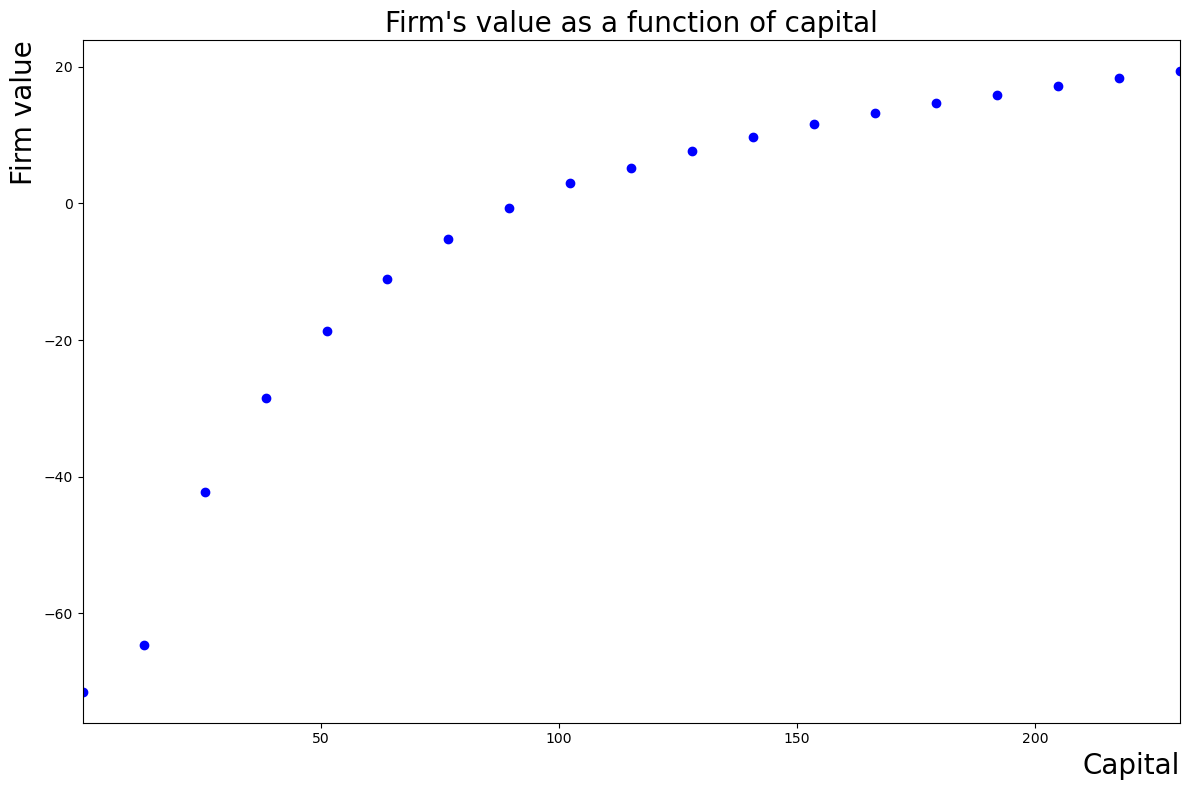

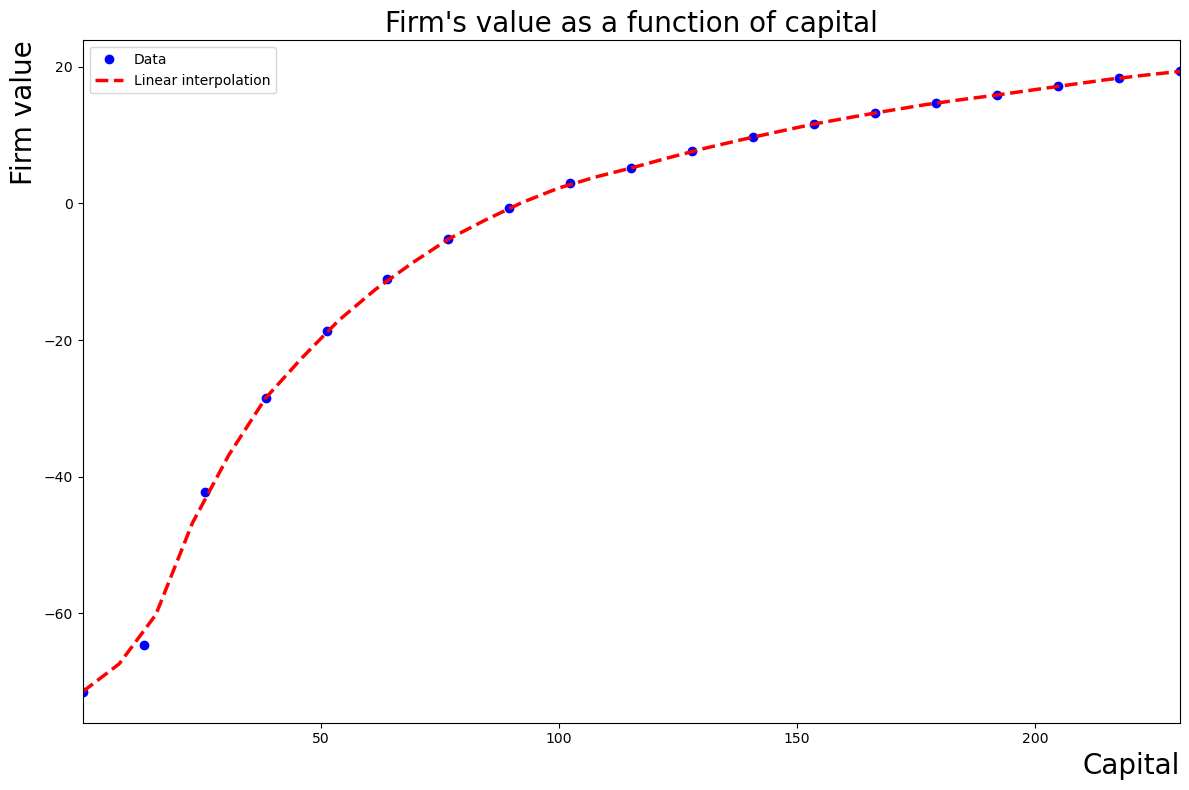

In [2]:
#---------interpolation----------------
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

fname = 'k.csv'
capital = np.genfromtxt(fname, skip_header=1)
fname = 'v.csv'
fvalue = np.genfromtxt(fname, skip_header=1, delimiter=",")

k = capital[0:19]
v = fvalue[0:19,7]

lwidth=2.5
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(k,v, "o", color="blue",label="Value function")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Firm's value as a function of capital", fontsize=20)
plt.xlabel("Capital", loc='right',fontsize=20)
ax.set_ylabel("Firm value", loc='top',fontsize=20)
#ax.legend(loc='best')
fig.tight_layout()
plt.show()

#---piecewise linear interpolation
from scipy import interpolate as itp
vLinear = itp.interp1d(k, v, kind='linear')
knew = np.linspace(k[0], k[-1], num=31, endpoint=True)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(k,v, "o", color="blue",label="Data")
ax.plot(knew, vLinear(knew), color="red", linewidth=lwidth, linestyle="--",label="Linear interpolation")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Firm's value as a function of capital", fontsize=20)
plt.xlabel("Capital", loc='right',fontsize=20)
ax.set_ylabel("Firm value", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


**Example**: Linear programming. Solve the following problem:
\begin{align*}
\begin{matrix}
  \max &  -x_1 & + & 3x_2 & - & 3x_3 &  & \\
  \mathrm{s.t.}& 3x_1 & - & x_2 & - & 2x_3 & \le & 7 \\
& -2x_1 & - & 4x_2 & + & 4x_3 & \le & 3 \\
& x_1 &  &  & - & 2x_3 & \le & 4 \\
& -2x_1 & + & 2x_2 & + & x_3 & \le & 8 \\
& 3x_1 &&&&& \le & 5 \\
&& & x_1, & x_2, & x_3 & \ge & 0 \end{matrix}
\end{align*}

In [3]:
#use Scipy interior-point method, problem is the example in explaining Simplex
import numpy as np
from scipy.optimize import linprog
c = [1.0, -3.0, 3.0]
A1 = np.array([[3.0, -2.0, 1.0, -2.0, 3.0, -1.0, 0.0, 0.0], 
                [-1.0, -4.0, 0.0, 2.0, 0.0, 0.0, -1.0, 0.0],
                [-2.0, 4.0, -2.0, 1.0, 0.0, 0.0, 0.0, -1.0]])
A = A1[0:3,0:5].T
b = [7.0, 3.0, 4.0, 8.0, 5.0]
x1_bounds = (0, None)
x2_bounds = x1_bounds
x3_bounds = x2_bounds
#res = linprog(c, A_ub=A, b_ub=b, bounds=[x0_bounds, x1_bounds])
# default bounds are (0, None)
res = linprog(c=c, A_ub=A, b_ub=b, method='highs')
print(res)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -15.333333333333334
              x: [ 1.667e+00  5.667e+00  0.000e+00]
            nit: 0
          lower:  residual: [ 1.667e+00  5.667e+00  0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  4.500e+00]
          upper:  residual: [       inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 7.667e+00  2.900e+01  2.333e+00  0.000e+00
                              0.000e+00]
                 marginals: [-0.000e+00 -0.000e+00 -0.000e+00 -1.500e+00
                             -6.667e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


**Example**: nonlinear optimization.

Minimize function $f(x) = 5x^4 + 3x^3 - 7x^2 - x + 2$ on interval $[-1.5,1.5]$.

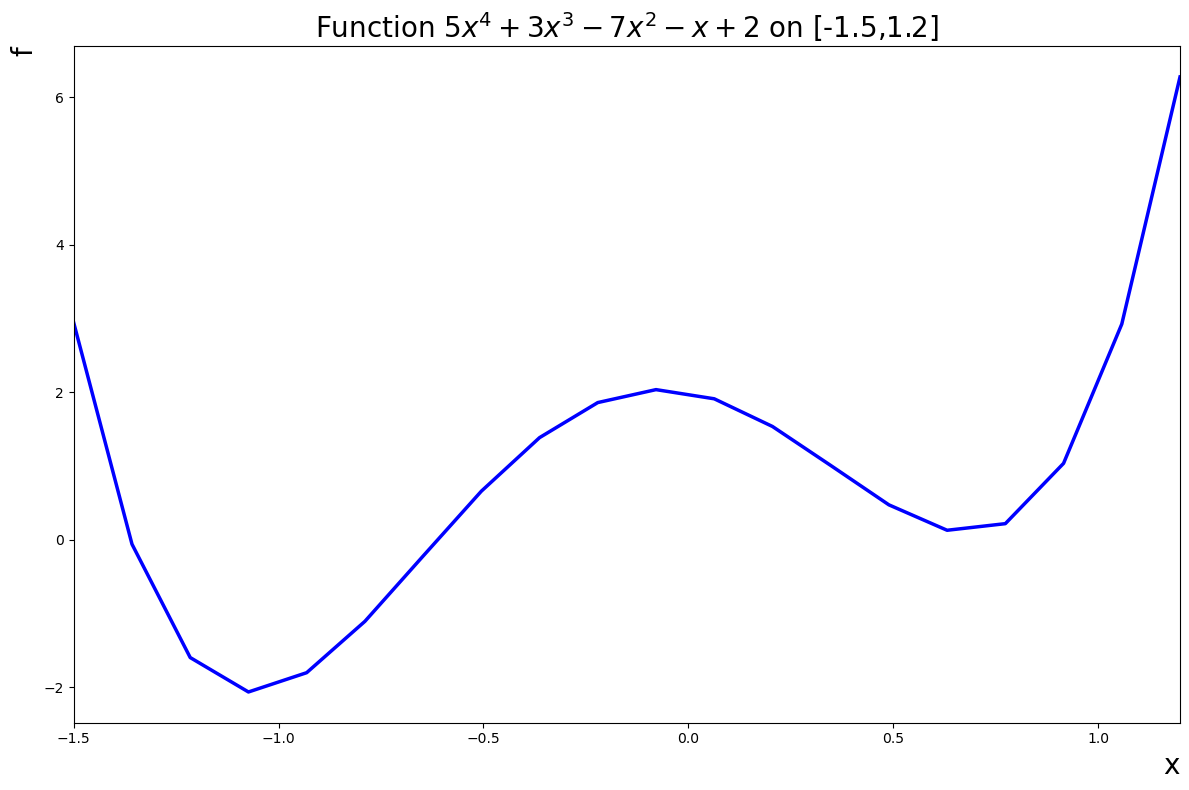

In [4]:
#---a function with two local minimals
x = np.linspace(-1.5, 1.2, num=20, endpoint=True)
ffun = lambda x: 5.0*x**4 + 3.0*x**3 - 7.0*x**2 - x + 2.0
lwidth=2.5
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, ffun(x), color="blue", linewidth=lwidth, linestyle="-")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Function $5x^4+3x^3-7x^2-x+2$ on [-1.5,1.2]", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
fig.tight_layout()
plt.show()

In [5]:
##---BFGS, requires derivative
from scipy.optimize import minimize
f_der = lambda x: 20.0*x**3 + 9.0*x**2 - 14.0*x -1.0
x0=-1.0
xminBFGS = minimize(ffun, x0, method='BFGS', jac = f_der)
xminBFGS

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -2.066116207892515
        x: [-1.064e+00]
      nit: 4
      jac: [ 8.116e-07]
 hess_inv: [[ 2.873e-02]]
     nfev: 6
     njev: 6